In [46]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
DATASET_DIR = r"D:\Datasets\MinimarketPointCloud\MiniMarket_raw"

object_folder_names = os.listdir(DATASET_DIR)
object_names = []
for object_folder in object_folder_names:
    object_dir = os.path.join(DATASET_DIR, object_folder)
    if os.path.isdir(object_dir):
        object_samples = os.listdir(object_dir)
        for object_sample in object_samples:
            object_name = object_folder + "_sampleconds_" + object_sample.split(".")[0]
            object_names.append(object_name)
num_objects = len(object_names)
print(f"Number of objects: {num_objects}")

Number of objects: 98400


In [76]:
df_objects = pd.DataFrame(object_names,columns=["name_object_and_sampleconds"]) # ,columns=["object","num_samples"]).sort_values(by="num_samples",ascending=False).reset_index(drop=True)
df_objects["name_object"] = df_objects.name_object_and_sampleconds.str.split("_sampleconds_").str[0]
df_objects["sample_conds"] = df_objects.name_object_and_sampleconds.str.split("_sampleconds_").str[1]
df_objects["object_class"] = df_objects.name_object.str.split("_").str[0]
display(df_objects.head(5))
# df_objects_class = df_objects.groupby("object_class").sum().sort_values(by="num_samples",ascending=False)
# display(df_objects_class.head(5))
# avg_samples = df_objects["num_samples"].mean()  
# print(f"Average samples per object: {avg_samples}")
df_objects_class = df_objects.groupby("object_class").count().sort_values(by="name_object_and_sampleconds",ascending=False)
display(df_objects_class)
avg_samples = df_objects_class["name_object_and_sampleconds"].mean()  
print(f"Average samples per object class: {avg_samples}")
df_objects_name = df_objects.groupby("name_object").count().sort_values(by="name_object_and_sampleconds",ascending=False)
display(df_objects_name)
num_objects = len(df_objects_name)
print(f"Number of objects: {num_objects}")

,name_object_and_sampleconds,name_object,sample_conds,object_class
0,biscuits_belvita_breakfast_biscuits_golden_oat...,biscuits_belvita_breakfast_biscuits_golden_oat...,angle_10_light_1_noise_1_cam1,biscuits
1,biscuits_belvita_breakfast_biscuits_golden_oat...,biscuits_belvita_breakfast_biscuits_golden_oat...,angle_10_light_1_noise_1_cam2,biscuits
2,biscuits_belvita_breakfast_biscuits_golden_oat...,biscuits_belvita_breakfast_biscuits_golden_oat...,angle_10_light_1_noise_1_cam3,biscuits
3,biscuits_belvita_breakfast_biscuits_golden_oat...,biscuits_belvita_breakfast_biscuits_golden_oat...,angle_10_light_1_noise_1_cam4,biscuits
4,biscuits_belvita_breakfast_biscuits_golden_oat...,biscuits_belvita_breakfast_biscuits_golden_oat...,angle_10_light_1_noise_1_cam5,biscuits


,name_object_and_sampleconds,name_object,sample_conds
object_class,,,
soap,9600,9600,9600
liquid,8400,8400,8400
tooth,6000,6000,6000
jam,6000,6000,6000
coffee,6000,6000,6000
shampoo,6000,6000,6000
microwave,6000,6000,6000
shower,6000,6000,6000
cereal,4800,4800,4800


Average samples per object class: 3784.6153846153848


,name_object_and_sampleconds,sample_conds,object_class
name_object,,,
biscuit_spread_lotus_400gm,1200,1200,1200
soap_bar_dove_original_beauty_cream_bar_1x_90gm,1200,1200,1200
shower_gel_original_source_mint_and_tea_tree_250ml,1200,1200,1200
shower_gel_original_source_coconut_and_shea_butter_250ml,1200,1200,1200
shower_cream_palmolive_naturals_milk_and_honey_250ml,1200,1200,1200
...,...,...,...
jam_bonne_maman_raspberry_conserve_370gm,1200,1200,1200
jam_bonne_maman_bitter_orange_fine_marmalade_370gm,1200,1200,1200
hot_choc_instant_galaxy_370gm,1200,1200,1200


Number of objects: 82


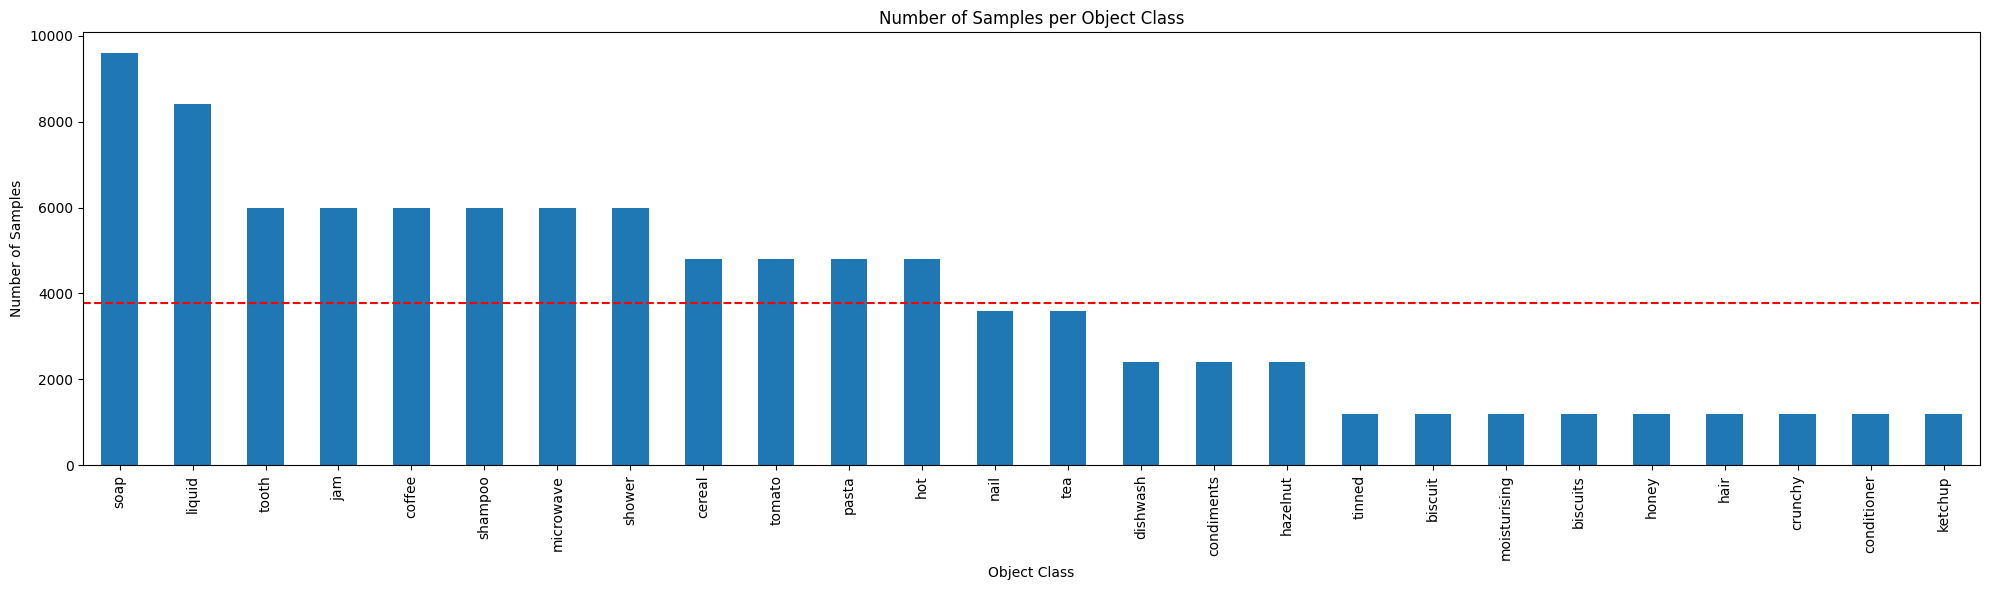

In [73]:

# Bar plot of the number of samples for each object class
df_objects_class.plot(y='name_object_and_sampleconds', kind='bar', figsize=(20, 6), legend=False)
plt.title('Number of Samples per Object Class')
plt.xlabel('Object Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=90)
plt.axhline(avg_samples, color='r', linestyle='--', label='Average Samples')
plt.tight_layout()
plt.show()

c:\Users\jorge\anaconda3\envs\pointnet\lib\site-packages\ipykernel_launcher.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  import sys


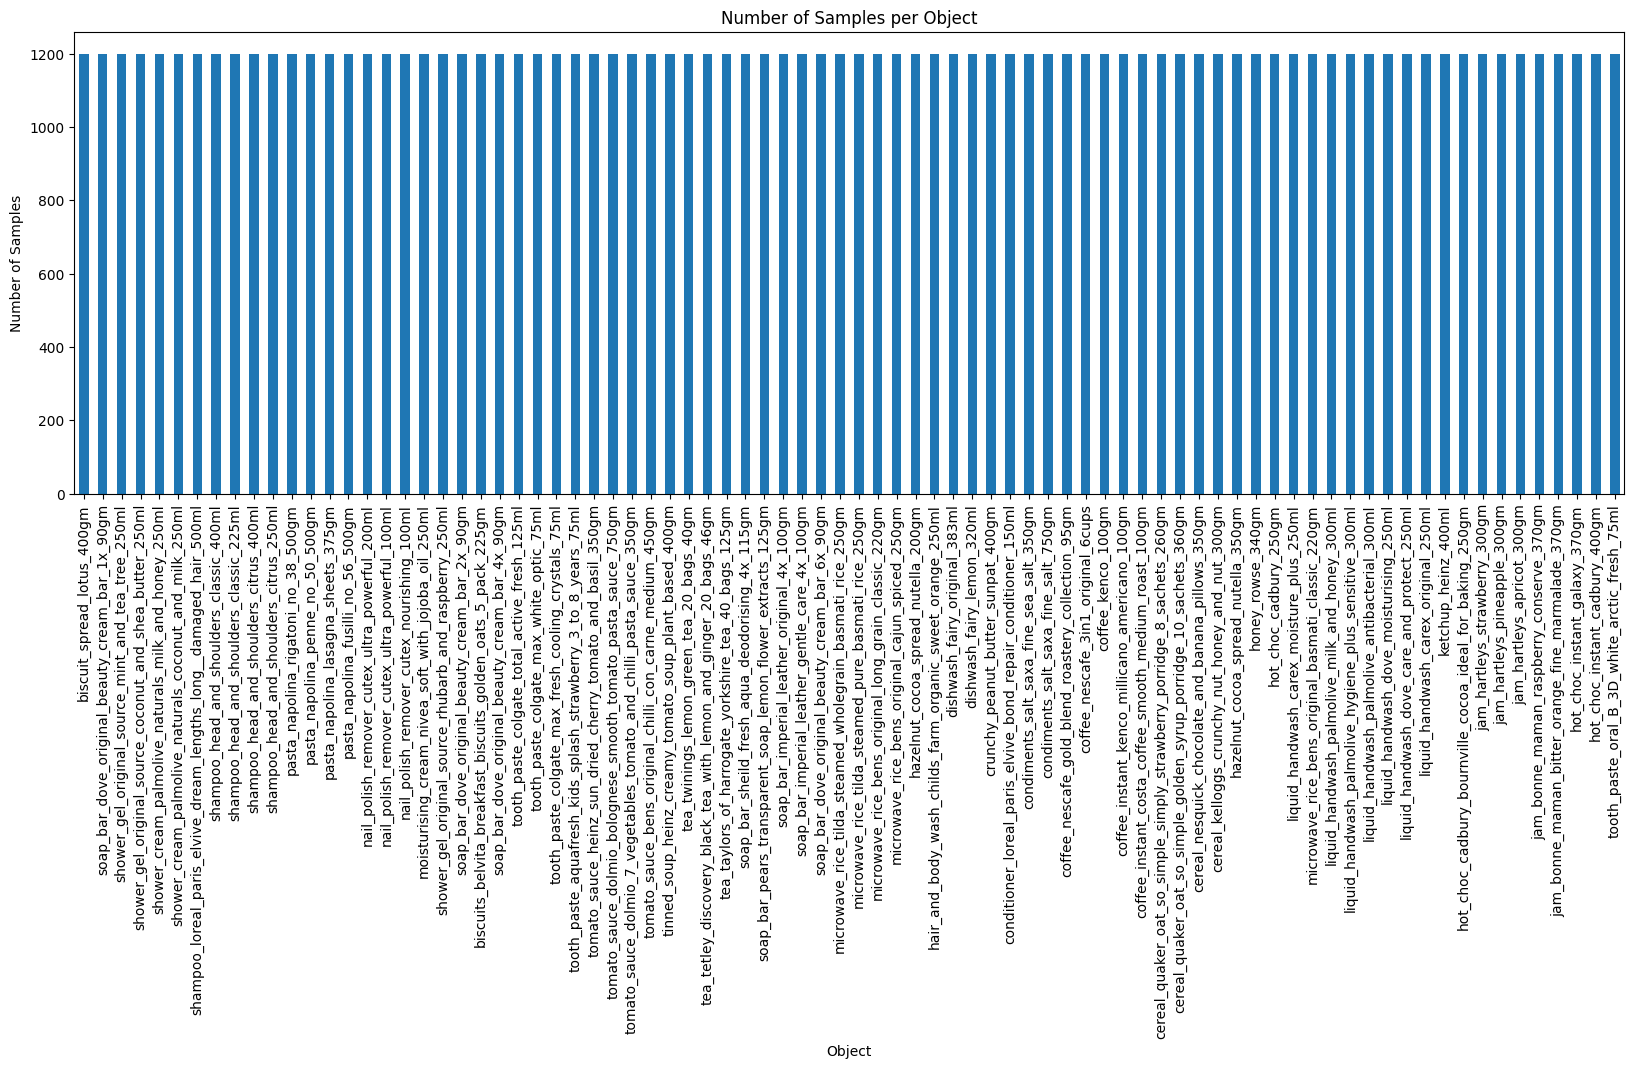

In [75]:

# Bar plot of the number of samples for each object
df_objects_name.plot(y='name_object_and_sampleconds', kind='bar', figsize=(20, 6), legend=False)
plt.title('Number of Samples per Object')
plt.xlabel('Object')
plt.ylabel('Number of Samples')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [89]:
print("Types of objects per class:")
df_objects.drop_duplicates(["name_object"],inplace=True)
df_objects.value_counts("object_class").sort_values(ascending=False).head(10)

Types of objects per class:


object_class
soap         8
liquid       7
tooth        5
jam          5
coffee       5
shampoo      5
microwave    5
shower       5
cereal       4
tomato       4
dtype: int64